In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [15]:
a = 1.0

In [16]:
def original_system(t, state):
    x, y = state

    dx = a * x**2 - 2 * x * y
    dy = y**2 - a * x * y

    return [dx, dy]

In [17]:
def x_blowup_system(tau, state):
    x, z = state

    dx = x * (a - 2 * z)
    dz = z * (3 * z - 2 * a)

    return [dx, dz]

In [18]:
def y_blowup_system(tau, state):
    w, y = state

    dw = w * (2 * a * w - 3)
    dy = y * (1 - a * w)

    return [dw, dy]

In [19]:
def plot_vector_field(
    ax,
    system,
    xlim,
    ylim,
    xlabel,
    ylabel,
    title,
    density=1.1
):
    x_values = np.linspace(xlim[0], xlim[1], 41)
    y_values = np.linspace(ylim[0], ylim[1], 41)

    X, Y = np.meshgrid(x_values, y_values)

    U = np.zeros_like(X)
    V = np.zeros_like(Y)

    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            U[i, j], V[i, j] = system(0, [X[i, j], Y[i, j]])

    magnitude = np.sqrt(U**2 + V**2)

    # 크기보다 방향을 보기 위한 정규화
    U = U / (magnitude + 1e-12)
    V = V / (magnitude + 1e-12)

    ax.streamplot(
        X,
        Y,
        U,
        V,
        density=density,
        linewidth=0.8,
        arrowsize=1.0
    )

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)


In [20]:
def add_trajectories(
    ax,
    system,
    initial_conditions,
    t_span=(-3, 3),
    max_step=0.01
):
    for initial_state in initial_conditions:

        # forward trajectory
        sol_forward = solve_ivp(
            system,
            (0, t_span[1]),
            initial_state,
            max_step=max_step,
            rtol=1e-9,
            atol=1e-11
        )

        # backward trajectory
        sol_backward = solve_ivp(
            system,
            (0, t_span[0]),
            initial_state,
            max_step=max_step,
            rtol=1e-9,
            atol=1e-11
        )

        ax.plot(
            sol_forward.y[0],
            sol_forward.y[1],
            linewidth=1.3
        )

        ax.plot(
            sol_backward.y[0],
            sol_backward.y[1],
            linewidth=1.3
        )

        ax.scatter(
            initial_state[0],
            initial_state[1],
            s=18,
            zorder=5
        )

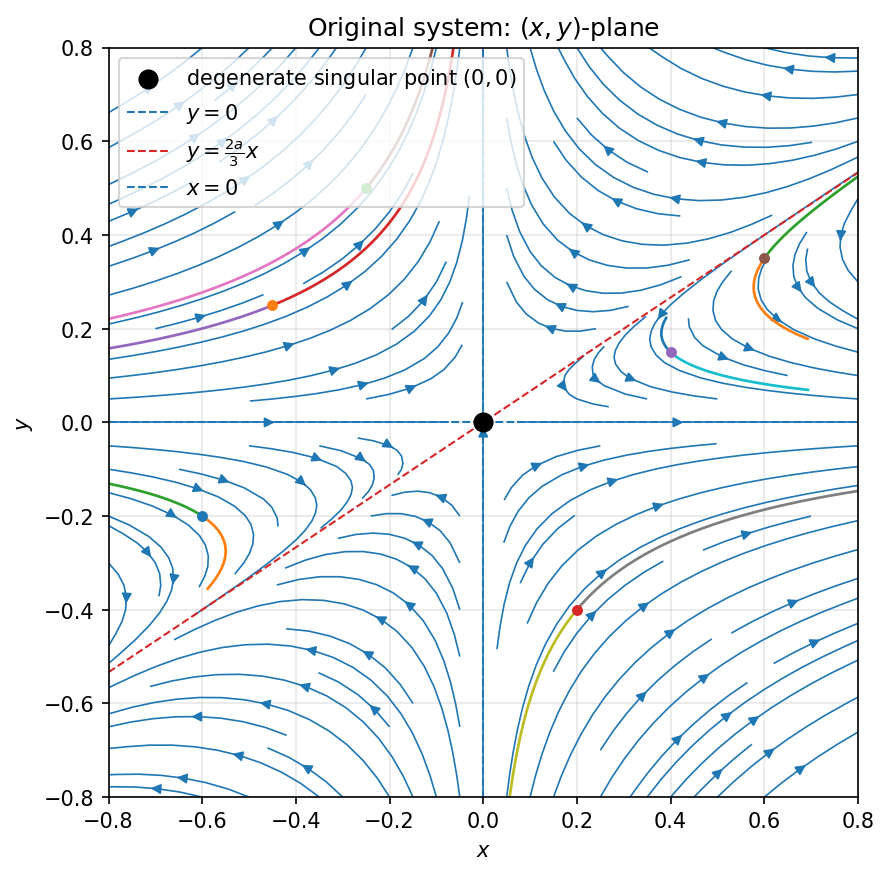

In [21]:
fig_original, ax_original = plt.subplots(figsize=(6, 6), dpi=150)

plot_vector_field(
    ax=ax_original,
    system=original_system,
    xlim=(-0.8, 0.8),
    ylim=(-0.8, 0.8),
    xlabel=r"$x$",
    ylabel=r"$y$",
    title=r"Original system: $(x,y)$-plane"
)

original_initial_conditions = [
    (-0.60, -0.20),
    (-0.45, 0.25),
    (-0.25, 0.50),
    (0.20, -0.40),
    (0.40, 0.15),
    (0.60, 0.35)
]

add_trajectories(
    ax=ax_original,
    system=original_system,
    initial_conditions=original_initial_conditions,
    t_span=(-2, 2)
)

ax_original.scatter(
    0,
    0,
    s=75,
    color="black",
    zorder=6,
    label=r"degenerate singular point $(0,0)$"
)

# characteristic directions
ax_original.axhline(
    0,
    linestyle="--",
    linewidth=1.0,
    label=r"$y=0$"
)

x_line = np.linspace(-0.8, 0.8, 200)
ax_original.plot(
    x_line,
    (2 * a / 3) * x_line,
    linestyle="--",
    linewidth=1.0,
    label=rf"$y=\frac{{2a}}{{3}}x$"
)

ax_original.axvline(
    0,
    linestyle="--",
    linewidth=1.0,
    label=r"$x=0$"
)

ax_original.set_aspect("equal", adjustable="box")
ax_original.legend(loc="upper left")

plt.tight_layout()
plt.savefig("Original_system_2.png", dpi=300, bbox_inches="tight")
plt.show()


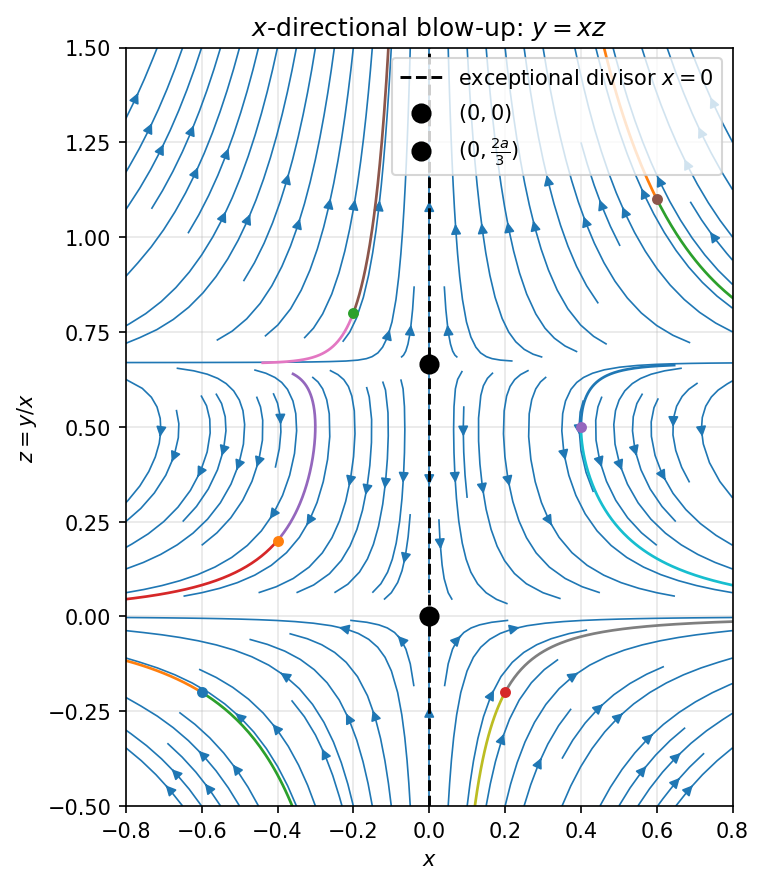

In [22]:
fig_x_blowup, ax_x_blowup = plt.subplots(figsize=(6, 6), dpi=150)

plot_vector_field(
    ax=ax_x_blowup,
    system=x_blowup_system,
    xlim=(-0.8, 0.8),
    ylim=(-0.5, 1.5),
    xlabel=r"$x$",
    ylabel=r"$z=y/x$",
    title=r"$x$-directional blow-up: $y=xz$"
)

x_blowup_initial_conditions = [
    (-0.60, -0.20),
    (-0.40, 0.20),
    (-0.20, 0.80),
    (0.20, -0.20),
    (0.40, 0.50),
    (0.60, 1.10)
]

add_trajectories(
    ax=ax_x_blowup,
    system=x_blowup_system,
    initial_conditions=x_blowup_initial_conditions,
    t_span=(-2, 2)
)

# exceptional divisor
ax_x_blowup.axvline(
    0,
    linestyle="--",
    linewidth=1.4,
    color="black",
    label=r"exceptional divisor $x=0$"
)

# singular points on exceptional divisor
ax_x_blowup.scatter(
    0,
    0,
    s=75,
    color="black",
    zorder=6,
    label=r"$(0,0)$"
)

ax_x_blowup.scatter(
    0,
    2 * a / 3,
    s=75,
    color="black",
    zorder=6,
    label=rf"$(0,\frac{{2a}}{{3}})$"
)

ax_x_blowup.set_aspect("equal", adjustable="box")
ax_x_blowup.legend(loc="upper right")

plt.tight_layout()
plt.savefig("Blow-Up_system_z.png", dpi=300, bbox_inches="tight")
plt.show()


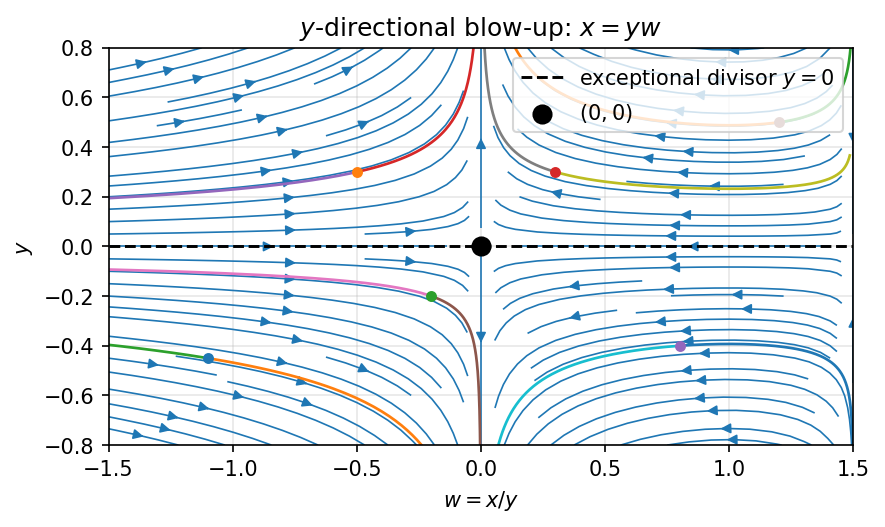

In [23]:
fig_y_blowup, ax_y_blowup = plt.subplots(figsize=(6, 6), dpi=150)

plot_vector_field(
    ax=ax_y_blowup,
    system=y_blowup_system,
    xlim=(-1.5, 1.5),
    ylim=(-0.8, 0.8),
    xlabel=r"$w=x/y$",
    ylabel=r"$y$",
    title=r"$y$-directional blow-up: $x=yw$"
)

y_blowup_initial_conditions = [
    (-1.10, -0.45),
    (-0.50, 0.30),
    (-0.20, -0.20),
    (0.30, 0.30),
    (0.80, -0.40),
    (1.20, 0.50)
]

add_trajectories(
    ax=ax_y_blowup,
    system=y_blowup_system,
    initial_conditions=y_blowup_initial_conditions,
    t_span=(-2, 2)
)

# exceptional divisor
ax_y_blowup.axhline(
    0,
    linestyle="--",
    linewidth=1.4,
    color="black",
    label=r"exceptional divisor $y=0$"
)

# singular point
ax_y_blowup.scatter(
    0,
    0,
    s=75,
    color="black",
    zorder=6,
    label=r"$(0,0)$"
)

ax_y_blowup.set_aspect("equal", adjustable="box")
ax_y_blowup.legend(loc="upper right")

plt.tight_layout()
plt.savefig("Blow-Up_system_y.png", dpi=300, bbox_inches="tight")
plt.show()

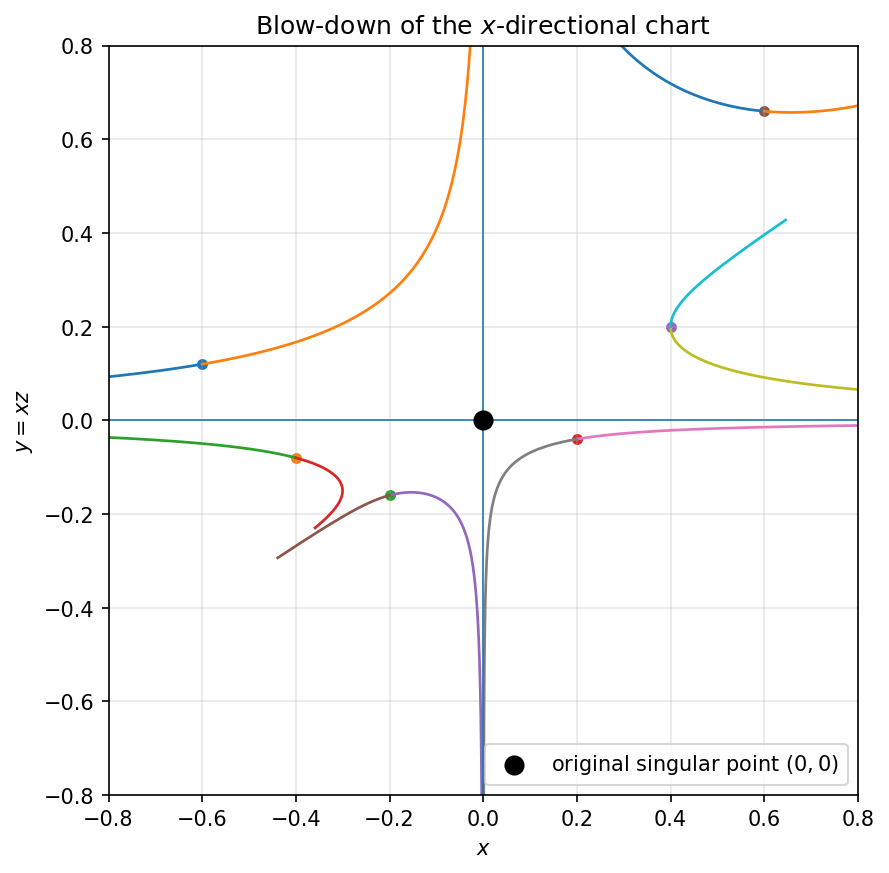

In [24]:
fig_blowdown, ax_blowdown = plt.subplots(figsize=(6, 6), dpi=150)

for initial_state in x_blowup_initial_conditions:

    sol_forward = solve_ivp(
        x_blowup_system,
        (0, 2),
        initial_state,
        max_step=0.01,
        rtol=1e-9,
        atol=1e-11
    )

    sol_backward = solve_ivp(
        x_blowup_system,
        (0, -2),
        initial_state,
        max_step=0.01,
        rtol=1e-9,
        atol=1e-11
    )

    for sol in [sol_forward, sol_backward]:
        x = sol.y[0]
        z = sol.y[1]

        # blow-down
        y = x * z

        ax_blowdown.plot(x, y, linewidth=1.3)

    x0, z0 = initial_state
    ax_blowdown.scatter(x0, x0 * z0, s=18)


ax_blowdown.scatter(
    0,
    0,
    s=75,
    color="black",
    zorder=6,
    label=r"original singular point $(0,0)$"
)

ax_blowdown.axhline(0, linewidth=0.8)
ax_blowdown.axvline(0, linewidth=0.8)

ax_blowdown.set_xlim(-0.8, 0.8)
ax_blowdown.set_ylim(-0.8, 0.8)

ax_blowdown.set_xlabel(r"$x$")
ax_blowdown.set_ylabel(r"$y=xz$")
ax_blowdown.set_title(
    r"Blow-down of the $x$-directional chart"
)

ax_blowdown.grid(True, alpha=0.3)
ax_blowdown.set_aspect("equal", adjustable="box")
ax_blowdown.legend()

plt.tight_layout()
plt.savefig("Blow-Down_system.png", dpi=300, bbox_inches="tight")
plt.show()